In [1]:
from __future__ import annotations

from itertools import product
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.model_selection import train_test_split

from catboost import CatBoostRegressor, Pool

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")





In [2]:
# -----------------------------------------------------------------------------
# Config
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path.cwd() / "notebook_exports"
ROUND_DATA_PATH = OUTPUT_DIR / "round_level_modeling_dataset_v1.parquet"

TEST_SIZE = 0.20
VALID_SIZE_WITHIN_TRAIN = 0.20
RANDOM_STATE = 42

USE_LAYOUT_ID = True
USE_DIVISION = True
REQUIRE_WEATHER_AVAILABLE = True

MPH_TO_MPS = 0.44704
MPS_TO_MPH = 2.23694

TARGET_COL = "actual_round_strokes"

# Stage 1: baseline score model with no weather features.
STAGE1_CATBOOST_PARAMS = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 10000,
    "depth": 6,
    "learning_rate": 0.03,
    "l2_leaf_reg": 8.0,
    "random_seed": RANDOM_STATE,
    "verbose": 250,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "max_ctr_complexity": 1,
    "store_all_simple_ctr": False,
    "task_type": "CPU",
}
STAGE1_EARLY_STOPPING_ROUNDS = 300

# Stage 2: smooth additive weather model.
STAGE2_SPLINE_FEATURES = [
    "round_wind_speed_mps_mean",
    "round_wind_gust_mps_mean",
    "round_temp_c_mean",
    "round_precip_mm_sum_log1p",
]
STAGE2_LINEAR_CONTROL_FEATURES = [
    "round_pressure_hpa_mean",
    "round_humidity_pct_mean",
]
STAGE2_RIDGE_ALPHAS = np.logspace(-3, 3, 25)

IDEAL_PRECIP_REFERENCE_MM = 0.0

print("Using local round dataset:", ROUND_DATA_PATH)


Using local round dataset: c:\Users\ryanc\dg_wind_effects\wind_impact_analysis\notebook_exports\round_level_modeling_dataset_v1.parquet


In [3]:
# -----------------------------------------------------------------------------
# Load data
# -----------------------------------------------------------------------------

round_level_df = pd.read_parquet(ROUND_DATA_PATH).copy()

print("Round-level shape:", round_level_df.shape)
round_level_df.head()


Round-level shape: (419842, 28)


,event_year,tourn_id,round_number,player_key,course_id,layout_id,division,player_rating,actual_round_strokes,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,round_strokes_over_par,round_length_over_par,wind_x_round_length,gust_x_round_length,wind_x_player_rating
0,2025,90004,1,PDGA#240866,248066,731340,MA4,777.0,60.0,18,4262.0,236.777778,54.0,3.000000,2.99,2.99,5.3,5.3,15.6,0.0,0.0,1018.5,82.0,6.0,78.925926,12743.38,22588.6,2323.23
1,2025,90022,1,PDGA#139372,303386,708703,MPO,944.0,65.0,22,6640.0,301.818182,69.0,3.136364,0.69,0.69,3.0,3.0,3.7,0.0,0.0,1009.0,83.0,-4.0,96.231884,4581.60,19920.0,651.36
2,2025,90022,1,PDGA#178707,303386,708703,FPO,921.0,67.0,22,6640.0,301.818182,69.0,3.136364,1.38,1.38,2.7,2.7,1.1,0.0,0.0,1009.0,91.0,-2.0,96.231884,9163.20,17928.0,1270.98
3,2025,90022,1,PDGA#235527,303386,708703,MA2,861.0,72.0,22,6640.0,301.818182,69.0,3.136364,1.25,1.25,2.3,2.3,2.2,0.0,0.0,1009.7,89.0,3.0,96.231884,8300.00,15272.0,1076.25
4,2025,90022,2,PDGA#208891,303386,708709,MA50,887.0,79.0,22,7337.0,333.500000,70.0,3.181818,1.71,1.71,4.2,4.2,5.5,0.0,0.0,1004.7,77.0,9.0,104.814286,12546.27,30815.4,1516.77


In [4]:
# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------

def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


def prepare_two_stage_frame(
    df: pd.DataFrame,
    *,
    stage1_numeric_features: list[str],
    stage1_categorical_features: list[str],
    stage2_raw_numeric_features: list[str],
    target_col: str,
) -> pd.DataFrame:
    out = df.copy()

    required_cols = (
        [target_col]
        + stage1_numeric_features
        + stage1_categorical_features
        + stage2_raw_numeric_features
    )
    missing = [c for c in required_cols if c not in out.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    numeric_cols = [target_col] + stage1_numeric_features + stage2_raw_numeric_features
    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).copy()

    for col in stage1_categorical_features:
        out[col] = out[col].astype("string").fillna("__MISSING__").astype(str)

    return out


def build_stage1_pool(
    df: pd.DataFrame,
    *,
    stage1_feature_cols: list[str],
    stage1_categorical_features: list[str],
    target_col: str | None = None,
) -> Pool:
    cat_idx = [stage1_feature_cols.index(c) for c in stage1_categorical_features]

    if target_col is not None:
        return Pool(
            data=df[stage1_feature_cols],
            label=df[target_col],
            cat_features=cat_idx,
        )

    return Pool(
        data=df[stage1_feature_cols],
        cat_features=cat_idx,
    )


def build_stage2_design_df(
    base_df: pd.DataFrame,
    *,
    wind_speed_mps: float | None = None,
    wind_gust_mps: float | None = None,
    temp_c: float | None = None,
    precip_mm: float | None = None,
    pressure_hpa: float | None = None,
    humidity_pct: float | None = None,
) -> pd.DataFrame:
    out = pd.DataFrame(index=base_df.index)

    out["round_wind_speed_mps_mean"] = (
        wind_speed_mps if wind_speed_mps is not None else pd.to_numeric(base_df["round_wind_speed_mps_mean"], errors="coerce")
    )
    out["round_wind_gust_mps_mean"] = (
        wind_gust_mps if wind_gust_mps is not None else pd.to_numeric(base_df["round_wind_gust_mps_mean"], errors="coerce")
    )
    out["round_temp_c_mean"] = (
        temp_c if temp_c is not None else pd.to_numeric(base_df["round_temp_c_mean"], errors="coerce")
    )
    out["round_precip_mm_sum"] = (
        precip_mm if precip_mm is not None else pd.to_numeric(base_df["round_precip_mm_sum"], errors="coerce")
    )
    out["round_pressure_hpa_mean"] = (
        pressure_hpa if pressure_hpa is not None else pd.to_numeric(base_df["round_pressure_hpa_mean"], errors="coerce")
    )
    out["round_humidity_pct_mean"] = (
        humidity_pct if humidity_pct is not None else pd.to_numeric(base_df["round_humidity_pct_mean"], errors="coerce")
    )

    out["round_precip_mm_sum"] = out["round_precip_mm_sum"].clip(lower=0.0)
    out["round_precip_mm_sum_log1p"] = np.log1p(out["round_precip_mm_sum"])

    design_df = out[
        [
            "round_wind_speed_mps_mean",
            "round_wind_gust_mps_mean",
            "round_temp_c_mean",
            "round_precip_mm_sum_log1p",
            "round_pressure_hpa_mean",
            "round_humidity_pct_mean",
        ]
    ].copy()

    return design_df


def build_effect_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for metric in [
        "estimated_wind_effect_vs_ideal",
        "estimated_temperature_effect_vs_ideal",
        "estimated_precip_effect_vs_ideal",
        "estimated_total_weather_effect_vs_ideal",
    ]:
        rows.append(
            {
                "metric": metric,
                "mean": float(df[metric].mean()),
                "median": float(df[metric].median()),
                "std": float(df[metric].std()),
                "p10": float(df[metric].quantile(0.10)),
                "p90": float(df[metric].quantile(0.90)),
            }
        )
    return pd.DataFrame(rows)


def build_stage2_effect_curve(
    *,
    base_df: pd.DataFrame,
    stage2_model,
    build_actual_design_fn,
    build_reference_design_fn,
    grid_values: list[float],
) -> pd.DataFrame:
    rows = []

    for grid_value in grid_values:
        actual_design = build_actual_design_fn(base_df.copy(), grid_value)
        reference_design = build_reference_design_fn(base_df.copy(), grid_value)

        actual_pred = stage2_model.predict(actual_design)
        reference_pred = stage2_model.predict(reference_design)
        effect_values = actual_pred - reference_pred

        rows.append(
            {
                "grid_value": grid_value,
                "effect_mean": float(np.mean(effect_values)),
                "effect_median": float(np.median(effect_values)),
                "effect_std": float(np.std(effect_values)),
                "effect_p10": float(np.quantile(effect_values, 0.10)),
                "effect_p90": float(np.quantile(effect_values, 0.90)),
            }
        )

    return pd.DataFrame(rows)


def build_stage2_score_curve(
    *,
    base_df: pd.DataFrame,
    stage2_model,
    build_design_fn,
    grid_values: list[float],
) -> pd.DataFrame:
    rows = []

    for grid_value in grid_values:
        design_df = build_design_fn(base_df.copy(), grid_value)
        pred = stage2_model.predict(design_df)

        rows.append(
            {
                "grid_value": grid_value,
                "prediction_mean": float(np.mean(pred)),
                "prediction_median": float(np.median(pred)),
                "prediction_std": float(np.std(pred)),
                "prediction_p10": float(np.quantile(pred, 0.10)),
                "prediction_p90": float(np.quantile(pred, 0.90)),
            }
        )

    return pd.DataFrame(rows)


def total_variation(values: pd.Series) -> float:
    diffs = np.diff(values.to_numpy(dtype=float))
    return float(np.abs(diffs).sum())


def second_difference_roughness(values: pd.Series) -> float:
    arr = values.to_numpy(dtype=float)
    if len(arr) < 3:
        return 0.0
    return float(np.abs(np.diff(arr, n=2)).sum())


In [5]:
# -----------------------------------------------------------------------------
# Feature setup
# -----------------------------------------------------------------------------

model_df = round_level_df.copy()

if REQUIRE_WEATHER_AVAILABLE and "weather_available_flag" in model_df.columns:
    model_df = model_df[model_df["weather_available_flag"] == True].copy()

STAGE1_NUMERIC_FEATURES = [
    "player_rating",
    "round_number",
    "hole_count",
    "round_total_hole_length",
    "round_avg_hole_length",
    "round_total_par",
    "round_avg_hole_par",
    "round_length_over_par",
]

STAGE1_CATEGORICAL_FEATURES = [
    "course_id",
]

if USE_DIVISION:
    STAGE1_CATEGORICAL_FEATURES.append("division")

if USE_LAYOUT_ID:
    STAGE1_CATEGORICAL_FEATURES.append("layout_id")

STAGE2_RAW_NUMERIC_FEATURES = [
    "round_wind_speed_mps_mean",
    "round_wind_gust_mps_mean",
    "round_temp_c_mean",
    "round_precip_mm_sum",
    "round_pressure_hpa_mean",
    "round_humidity_pct_mean",
]

EXPERIMENT_NAME = "two_stage_baseline_catboost_weather_splines"

print("Stage 1 numeric features:", STAGE1_NUMERIC_FEATURES)
print("Stage 1 categorical features:", STAGE1_CATEGORICAL_FEATURES)
print("Stage 2 raw numeric features:", STAGE2_RAW_NUMERIC_FEATURES)


Stage 1 numeric features: ['player_rating', 'round_number', 'hole_count', 'round_total_hole_length', 'round_avg_hole_length', 'round_total_par', 'round_avg_hole_par', 'round_length_over_par']
Stage 1 categorical features: ['course_id', 'division', 'layout_id']
Stage 2 raw numeric features: ['round_wind_speed_mps_mean', 'round_wind_gust_mps_mean', 'round_temp_c_mean', 'round_precip_mm_sum', 'round_pressure_hpa_mean', 'round_humidity_pct_mean']


In [6]:
# -----------------------------------------------------------------------------
# Train / validation / test split
# -----------------------------------------------------------------------------

train_full_df, test_df = train_test_split(
    model_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_df, valid_df = train_test_split(
    train_full_df,
    test_size=VALID_SIZE_WITHIN_TRAIN,
    random_state=RANDOM_STATE,
)

train_prepped = prepare_two_stage_frame(
    train_df,
    stage1_numeric_features=STAGE1_NUMERIC_FEATURES,
    stage1_categorical_features=STAGE1_CATEGORICAL_FEATURES,
    stage2_raw_numeric_features=STAGE2_RAW_NUMERIC_FEATURES,
    target_col=TARGET_COL,
)
valid_prepped = prepare_two_stage_frame(
    valid_df,
    stage1_numeric_features=STAGE1_NUMERIC_FEATURES,
    stage1_categorical_features=STAGE1_CATEGORICAL_FEATURES,
    stage2_raw_numeric_features=STAGE2_RAW_NUMERIC_FEATURES,
    target_col=TARGET_COL,
)
test_prepped = prepare_two_stage_frame(
    test_df,
    stage1_numeric_features=STAGE1_NUMERIC_FEATURES,
    stage1_categorical_features=STAGE1_CATEGORICAL_FEATURES,
    stage2_raw_numeric_features=STAGE2_RAW_NUMERIC_FEATURES,
    target_col=TARGET_COL,
)

print("Train rows:", len(train_prepped))
print("Valid rows:", len(valid_prepped))
print("Test rows:", len(test_prepped))


Train rows: 268698
Valid rows: 67175
Test rows: 83969


In [7]:
# -----------------------------------------------------------------------------
# Train stage 1 baseline model
# -----------------------------------------------------------------------------

stage1_feature_cols = STAGE1_NUMERIC_FEATURES + STAGE1_CATEGORICAL_FEATURES

stage1_train_pool = build_stage1_pool(
    train_prepped,
    stage1_feature_cols=stage1_feature_cols,
    stage1_categorical_features=STAGE1_CATEGORICAL_FEATURES,
    target_col=TARGET_COL,
)
stage1_valid_pool = build_stage1_pool(
    valid_prepped,
    stage1_feature_cols=stage1_feature_cols,
    stage1_categorical_features=STAGE1_CATEGORICAL_FEATURES,
    target_col=TARGET_COL,
)
stage1_test_pool = build_stage1_pool(
    test_prepped,
    stage1_feature_cols=stage1_feature_cols,
    stage1_categorical_features=STAGE1_CATEGORICAL_FEATURES,
    target_col=TARGET_COL,
)

stage1_model = CatBoostRegressor(**STAGE1_CATBOOST_PARAMS)
stage1_model.fit(
    stage1_train_pool,
    eval_set=stage1_valid_pool,
    use_best_model=True,
    early_stopping_rounds=STAGE1_EARLY_STOPPING_ROUNDS,
)

stage1_best_iteration = getattr(stage1_model, "best_iteration_", None)

train_stage1_pred = stage1_model.predict(stage1_train_pool)
valid_stage1_pred = stage1_model.predict(stage1_valid_pool)
test_stage1_pred = stage1_model.predict(stage1_test_pool)

stage1_metrics_df = pd.DataFrame(
    [
        {"split": "train", **regression_metrics(train_prepped[TARGET_COL], train_stage1_pred)},
        {"split": "valid", **regression_metrics(valid_prepped[TARGET_COL], valid_stage1_pred)},
        {"split": "test", **regression_metrics(test_prepped[TARGET_COL], test_stage1_pred)},
    ]
)
stage1_metrics_df["model"] = "stage1_baseline"
stage1_metrics_df["best_iteration"] = stage1_best_iteration
stage1_metrics_df["feature_count"] = len(stage1_feature_cols)

stage1_metrics_df


0:	learn: 10.2876791	test: 10.1920522	best: 10.1920522 (0)	total: 288ms	remaining: 48m 1s
250:	learn: 4.5334887	test: 4.4029125	best: 4.4029125 (250)	total: 45.3s	remaining: 29m 19s
500:	learn: 4.3705716	test: 4.2453956	best: 4.2453956 (500)	total: 1m 22s	remaining: 26m 3s
750:	learn: 4.3020537	test: 4.1798058	best: 4.1798058 (750)	total: 1m 58s	remaining: 24m 13s
1000:	learn: 4.2593846	test: 4.1401008	best: 4.1401008 (1000)	total: 2m 33s	remaining: 23m
1250:	learn: 4.2255254	test: 4.1108861	best: 4.1108861 (1250)	total: 3m 10s	remaining: 22m 9s
1500:	learn: 4.1987178	test: 4.0887833	best: 4.0887833 (1500)	total: 3m 45s	remaining: 21m 17s
1750:	learn: 4.1757651	test: 4.0702620	best: 4.0702620 (1750)	total: 4m 19s	remaining: 20m 22s
2000:	learn: 4.1552988	test: 4.0539303	best: 4.0539303 (2000)	total: 4m 54s	remaining: 19m 36s
2250:	learn: 4.1376197	test: 4.0404195	best: 4.0404195 (2250)	total: 5m 28s	remaining: 18m 51s
2500:	learn: 4.1207295	test: 4.0276485	best: 4.0276485 (2500)	total:

,split,mae,rmse,r2,model,best_iteration,feature_count
0,train,2.871469,3.788494,0.868986,stage1_baseline,9999,11
1,valid,2.970604,3.871973,0.860591,stage1_baseline,9999,11
2,test,2.993091,3.940945,0.858240,stage1_baseline,9999,11


In [8]:
# -----------------------------------------------------------------------------
# Stage 1 feature importance
# -----------------------------------------------------------------------------

stage1_feature_importance_df = stage1_model.get_feature_importance(
    stage1_train_pool,
    prettified=True,
).rename(columns={"Feature Id": "feature", "Importances": "importance"})

stage1_feature_importance_df.head(25)


,feature,importance
0,round_total_par,35.485445
1,player_rating,27.298416
2,round_length_over_par,8.178968
3,round_total_hole_length,6.578254
4,layout_id,6.273055
5,course_id,5.631170
6,hole_count,3.987862
7,round_avg_hole_par,3.191397
8,round_avg_hole_length,2.086497
9,division,0.790057


In [9]:
# -----------------------------------------------------------------------------
# Build stage 2 residual targets and design matrices
# -----------------------------------------------------------------------------

train_residual_target = train_prepped[TARGET_COL] - train_stage1_pred
valid_residual_target = valid_prepped[TARGET_COL] - valid_stage1_pred
test_residual_target = test_prepped[TARGET_COL] - test_stage1_pred

X_stage2_train = build_stage2_design_df(train_prepped)
X_stage2_valid = build_stage2_design_df(valid_prepped)
X_stage2_test = build_stage2_design_df(test_prepped)

X_stage2_train.head()


,round_wind_speed_mps_mean,round_wind_gust_mps_mean,round_temp_c_mean,round_precip_mm_sum_log1p,round_pressure_hpa_mean,round_humidity_pct_mean
162475,2.61,6.9,24.9,0.0,1012.0,48.0
2395,1.68,3.1,21.0,0.0,1016.0,88.0
86847,1.30,4.4,11.9,0.0,1014.7,78.0
402157,2.33,3.9,2.3,0.0,1025.3,79.0
154397,1.86,3.6,26.2,0.0,1018.2,86.0


In [10]:
# -----------------------------------------------------------------------------
# Fit stage 2 smooth additive weather model
# -----------------------------------------------------------------------------

stage2_preprocessor = ColumnTransformer(
    transformers=[
        (
            "weather_splines",
            SplineTransformer(
                n_knots=6,
                degree=3,
                include_bias=False,
                extrapolation="constant",
            ),
            STAGE2_SPLINE_FEATURES,
        ),
        (
            "weather_controls",
            StandardScaler(),
            STAGE2_LINEAR_CONTROL_FEATURES,
        ),
    ],
    remainder="drop",
)

stage2_model = Pipeline(
    steps=[
        ("preprocessor", stage2_preprocessor),
        ("ridge", RidgeCV(alphas=STAGE2_RIDGE_ALPHAS)),
    ]
)

stage2_model.fit(X_stage2_train, train_residual_target)

train_stage2_pred = stage2_model.predict(X_stage2_train)
valid_stage2_pred = stage2_model.predict(X_stage2_valid)
test_stage2_pred = stage2_model.predict(X_stage2_test)

combined_train_pred = train_stage1_pred + train_stage2_pred
combined_valid_pred = valid_stage1_pred + valid_stage2_pred
combined_test_pred = test_stage1_pred + test_stage2_pred

stage2_ridge_alpha = stage2_model.named_steps["ridge"].alpha_

stage2_metrics_df = pd.DataFrame(
    [
        {"split": "train", **regression_metrics(train_residual_target, train_stage2_pred)},
        {"split": "valid", **regression_metrics(valid_residual_target, valid_stage2_pred)},
        {"split": "test", **regression_metrics(test_residual_target, test_stage2_pred)},
    ]
)
stage2_metrics_df["model"] = "stage2_weather_residual"
stage2_metrics_df["ridge_alpha"] = stage2_ridge_alpha

combined_metrics_df = pd.DataFrame(
    [
        {"split": "train", **regression_metrics(train_prepped[TARGET_COL], combined_train_pred)},
        {"split": "valid", **regression_metrics(valid_prepped[TARGET_COL], combined_valid_pred)},
        {"split": "test", **regression_metrics(test_prepped[TARGET_COL], combined_test_pred)},
    ]
)
combined_metrics_df["model"] = "combined_two_stage"
combined_metrics_df["stage1_best_iteration"] = stage1_best_iteration
combined_metrics_df["stage2_ridge_alpha"] = stage2_ridge_alpha

print("Stage 2 residual-model metrics")
display(stage2_metrics_df)

print("Combined two-stage metrics")
display(combined_metrics_df)


Stage 2 residual-model metrics


,split,mae,rmse,r2,model,ridge_alpha
0,train,2.861637,3.777047,0.006004,stage2_weather_residual,3.162278
1,valid,2.958950,3.858041,0.007069,stage2_weather_residual,3.162278
2,test,2.982599,3.928023,0.006491,stage2_weather_residual,3.162278


Combined two-stage metrics


,split,mae,rmse,r2,model,stage1_best_iteration,stage2_ridge_alpha
0,train,2.861637,3.777047,0.869776,combined_two_stage,9999,3.162278
1,valid,2.958950,3.858041,0.861593,combined_two_stage,9999,3.162278
2,test,2.982599,3.928023,0.859168,combined_two_stage,9999,3.162278


In [11]:
# -----------------------------------------------------------------------------
# Fixed nuisance-control values for ideal search
# -----------------------------------------------------------------------------

PRESSURE_CONTROL_REFERENCE_HPA = float(train_prepped["round_pressure_hpa_mean"].median())
HUMIDITY_CONTROL_REFERENCE_PCT = float(train_prepped["round_humidity_pct_mean"].median())

control_reference_df = pd.DataFrame(
    [
        {
            "pressure_control_reference_hpa": PRESSURE_CONTROL_REFERENCE_HPA,
            "humidity_control_reference_pct": HUMIDITY_CONTROL_REFERENCE_PCT,
        }
    ]
)

control_reference_df


,pressure_control_reference_hpa,humidity_control_reference_pct
0,1016.8,80.0


In [12]:
# -----------------------------------------------------------------------------
# Fixed nuisance-control values for ideal search
# -----------------------------------------------------------------------------

PRESSURE_CONTROL_REFERENCE_HPA = float(train_prepped["round_pressure_hpa_mean"].median())
HUMIDITY_CONTROL_REFERENCE_PCT = float(train_prepped["round_humidity_pct_mean"].median())

control_reference_df = pd.DataFrame(
    [
        {
            "pressure_control_reference_hpa": PRESSURE_CONTROL_REFERENCE_HPA,
            "humidity_control_reference_pct": HUMIDITY_CONTROL_REFERENCE_PCT,
        }
    ]
)

control_reference_df


,pressure_control_reference_hpa,humidity_control_reference_pct
0,1016.8,80.0


In [13]:
# -----------------------------------------------------------------------------
# Ideal search config
# -----------------------------------------------------------------------------

ideal_search_config = {
    "wind_speed_mph": [0.0, 1.0, 2.0, 3.0, 5.0, 8.0],
    "wind_gust_mph": [0.0, 2.0, 3.0, 5.0, 8.0, 12.0],
    "temperature_c": [10.0, 12.0, 15.0, 18.0, 21.0, 24.0],
}

ideal_search_grid_rows = []
for wind_speed_mph, wind_gust_mph, temperature_c in product(
    ideal_search_config["wind_speed_mph"],
    ideal_search_config["wind_gust_mph"],
    ideal_search_config["temperature_c"],
):
    if wind_gust_mph < wind_speed_mph:
        continue

    ideal_search_grid_rows.append(
        {
            "wind_speed_mph": wind_speed_mph,
            "wind_gust_mph": wind_gust_mph,
            "temperature_c": temperature_c,
            "temperature_f": (temperature_c * 9.0 / 5.0) + 32.0,
            "precip_mm": IDEAL_PRECIP_REFERENCE_MM,
        }
    )

ideal_weather_grid_df = pd.DataFrame(ideal_search_grid_rows)
print("Candidate weather combinations:", len(ideal_weather_grid_df))
ideal_weather_grid_df.head(20)

Candidate weather combinations: 150


,wind_speed_mph,wind_gust_mph,temperature_c,temperature_f,precip_mm
0,0.0,0.0,10.0,50.0,0.0
1,0.0,0.0,12.0,53.6,0.0
2,0.0,0.0,15.0,59.0,0.0
3,0.0,0.0,18.0,64.4,0.0
4,0.0,0.0,21.0,69.8,0.0
5,0.0,0.0,24.0,75.2,0.0
6,0.0,2.0,10.0,50.0,0.0
7,0.0,2.0,12.0,53.6,0.0
8,0.0,2.0,15.0,59.0,0.0
9,0.0,2.0,18.0,64.4,0.0


In [14]:
# -----------------------------------------------------------------------------
# Run ideal search on validation set
# -----------------------------------------------------------------------------

ideal_search_results = []

for _, candidate in ideal_weather_grid_df.iterrows():
    scenario_design_df = build_stage2_design_df(
        valid_prepped,
        wind_speed_mps=float(candidate["wind_speed_mph"]) * MPH_TO_MPS,
        wind_gust_mps=float(candidate["wind_gust_mph"]) * MPH_TO_MPS,
        temp_c=float(candidate["temperature_c"]),
        precip_mm=IDEAL_PRECIP_REFERENCE_MM,
        pressure_hpa=PRESSURE_CONTROL_REFERENCE_HPA,
        humidity_pct=HUMIDITY_CONTROL_REFERENCE_PCT,
    )

    weather_adjustment_pred = stage2_model.predict(scenario_design_df)
    combined_score_pred = valid_stage1_pred + weather_adjustment_pred

    ideal_search_results.append(
        {
            "wind_speed_mph": float(candidate["wind_speed_mph"]),
            "wind_gust_mph": float(candidate["wind_gust_mph"]),
            "temperature_c": float(candidate["temperature_c"]),
            "temperature_f": float(candidate["temperature_f"]),
            "precip_mm": IDEAL_PRECIP_REFERENCE_MM,
            "weather_adjustment_mean": float(np.mean(weather_adjustment_pred)),
            "weather_adjustment_median": float(np.median(weather_adjustment_pred)),
            "combined_predicted_round_strokes_mean": float(np.mean(combined_score_pred)),
            "combined_predicted_round_strokes_median": float(np.median(combined_score_pred)),
        }
    )

ideal_search_results_df = (
    pd.DataFrame(ideal_search_results)
    .sort_values(
        ["combined_predicted_round_strokes_mean", "combined_predicted_round_strokes_median"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)

ideal_search_results_df.head(20)


,wind_speed_mph,wind_gust_mph,temperature_c,temperature_f,precip_mm,weather_adjustment_mean,weather_adjustment_median,combined_predicted_round_strokes_mean,combined_predicted_round_strokes_median
0,2.0,2.0,24.0,75.2,0.0,-0.524673,-0.524673,61.889911,60.682083
1,3.0,3.0,24.0,75.2,0.0,-0.515907,-0.515907,61.898677,60.690849
2,2.0,2.0,21.0,69.8,0.0,-0.506131,-0.506131,61.908454,60.700626
3,3.0,3.0,21.0,69.8,0.0,-0.497364,-0.497364,61.917220,60.709392
4,2.0,2.0,18.0,64.4,0.0,-0.489707,-0.489707,61.924878,60.717050
5,3.0,3.0,18.0,64.4,0.0,-0.480940,-0.480940,61.933644,60.725816
6,2.0,2.0,15.0,59.0,0.0,-0.471189,-0.471189,61.943395,60.735567
7,3.0,3.0,15.0,59.0,0.0,-0.462423,-0.462423,61.952161,60.744333
8,2.0,3.0,24.0,75.2,0.0,-0.453520,-0.453520,61.961064,60.753236
9,2.0,2.0,12.0,53.6,0.0,-0.445784,-0.445784,61.968800,60.760972


In [15]:
# -----------------------------------------------------------------------------
# Best empirical ideal condition
# -----------------------------------------------------------------------------

empirical_ideal_weather_baseline = ideal_search_results_df.iloc[0].to_dict()

IDEAL_WIND_REFERENCE_MPH = float(empirical_ideal_weather_baseline["wind_speed_mph"])
IDEAL_WIND_GUST_REFERENCE_MPH = float(empirical_ideal_weather_baseline["wind_gust_mph"])
IDEAL_TEMPERATURE_REFERENCE_C = float(empirical_ideal_weather_baseline["temperature_c"])

ideal_reference_conditions_df = pd.DataFrame(
    [
        {
            "wind_speed_reference_mph": IDEAL_WIND_REFERENCE_MPH,
            "wind_gust_reference_mph": IDEAL_WIND_GUST_REFERENCE_MPH,
            "temperature_reference_c": IDEAL_TEMPERATURE_REFERENCE_C,
            "temperature_reference_f": (IDEAL_TEMPERATURE_REFERENCE_C * 9.0 / 5.0) + 32.0,
            "precip_reference_mm": IDEAL_PRECIP_REFERENCE_MM,
            "pressure_reference_hpa": PRESSURE_CONTROL_REFERENCE_HPA,
            "humidity_reference_pct": HUMIDITY_CONTROL_REFERENCE_PCT,
        }
    ]
)

ideal_reference_conditions_df


,wind_speed_reference_mph,wind_gust_reference_mph,temperature_reference_c,temperature_reference_f,precip_reference_mm,pressure_reference_hpa,humidity_reference_pct
0,2.0,2.0,24.0,75.2,0.0,1016.8,80.0


In [16]:
# -----------------------------------------------------------------------------
# Ideal-search boundary diagnostics
# -----------------------------------------------------------------------------

ideal_boundary_check_df = pd.DataFrame(
    [
        {
            "ideal_wind_speed_mph": IDEAL_WIND_REFERENCE_MPH,
            "ideal_wind_gust_mph": IDEAL_WIND_GUST_REFERENCE_MPH,
            "ideal_temperature_c": IDEAL_TEMPERATURE_REFERENCE_C,
            "ideal_temperature_f": (IDEAL_TEMPERATURE_REFERENCE_C * 9.0 / 5.0) + 32.0,
            "wind_speed_at_min_grid": IDEAL_WIND_REFERENCE_MPH == min(ideal_search_config["wind_speed_mph"]),
            "wind_speed_at_max_grid": IDEAL_WIND_REFERENCE_MPH == max(ideal_search_config["wind_speed_mph"]),
            "wind_gust_at_min_grid": IDEAL_WIND_GUST_REFERENCE_MPH == min(ideal_search_config["wind_gust_mph"]),
            "wind_gust_at_max_grid": IDEAL_WIND_GUST_REFERENCE_MPH == max(ideal_search_config["wind_gust_mph"]),
            "temperature_at_min_grid": IDEAL_TEMPERATURE_REFERENCE_C == min(ideal_search_config["temperature_c"]),
            "temperature_at_max_grid": IDEAL_TEMPERATURE_REFERENCE_C == max(ideal_search_config["temperature_c"]),
        }
    ]
)

ideal_boundary_check_df


,ideal_wind_speed_mph,ideal_wind_gust_mph,ideal_temperature_c,ideal_temperature_f,wind_speed_at_min_grid,wind_speed_at_max_grid,wind_gust_at_min_grid,wind_gust_at_max_grid,temperature_at_min_grid,temperature_at_max_grid
0,2.0,2.0,24.0,75.2,False,False,False,False,False,True


In [17]:
# -----------------------------------------------------------------------------
# Temperature slice diagnostic for ideal search
# -----------------------------------------------------------------------------

temperature_slice_df = (
    ideal_search_results_df.groupby(["temperature_c", "temperature_f"], dropna=False)
    .agg(
        best_combined_predicted_round_strokes_mean=("combined_predicted_round_strokes_mean", "min"),
        avg_combined_predicted_round_strokes_mean=("combined_predicted_round_strokes_mean", "mean"),
    )
    .reset_index()
    .sort_values("temperature_c")
)

temperature_slice_df


,temperature_c,temperature_f,best_combined_predicted_round_strokes_mean,avg_combined_predicted_round_strokes_mean
0,10.0,50.0,61.992164,62.282570
1,12.0,53.6,61.968800,62.259206
2,15.0,59.0,61.943395,62.233800
3,18.0,64.4,61.924878,62.215283
4,21.0,69.8,61.908454,62.198859
5,24.0,75.2,61.889911,62.180317


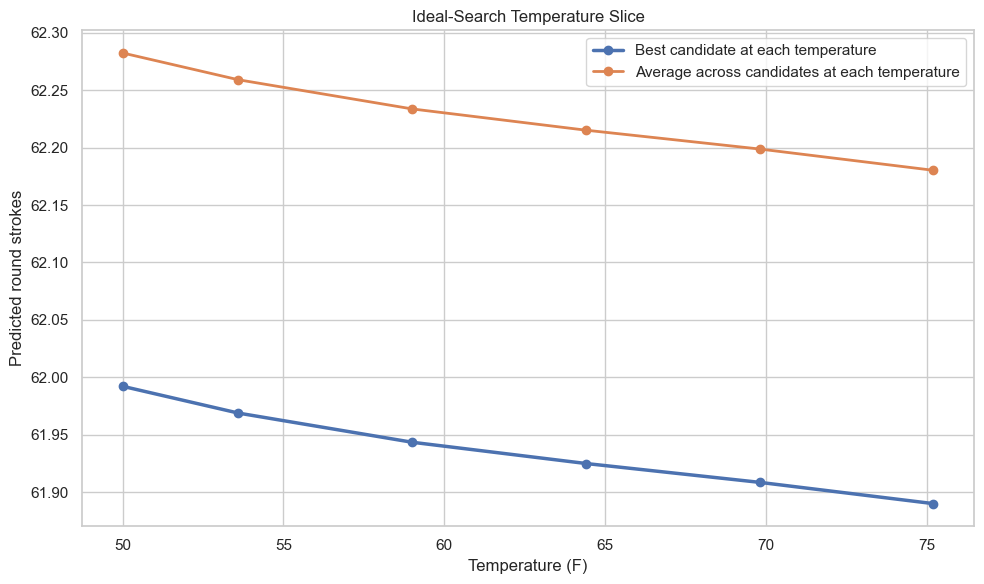

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(
    temperature_slice_df["temperature_f"],
    temperature_slice_df["best_combined_predicted_round_strokes_mean"],
    marker="o",
    linewidth=2.5,
    label="Best candidate at each temperature",
)
plt.plot(
    temperature_slice_df["temperature_f"],
    temperature_slice_df["avg_combined_predicted_round_strokes_mean"],
    marker="o",
    linewidth=2.0,
    label="Average across candidates at each temperature",
)
plt.title("Ideal-Search Temperature Slice")
plt.xlabel("Temperature (F)")
plt.ylabel("Predicted round strokes")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
# -----------------------------------------------------------------------------
# Score test rows under observed weather
# -----------------------------------------------------------------------------

scored_df = test_prepped.copy()

scored_df["predicted_round_strokes_stage1_baseline"] = test_stage1_pred
scored_df["predicted_weather_adjustment_observed"] = test_stage2_pred
scored_df["predicted_round_strokes"] = combined_test_pred
scored_df["round_residual_strokes"] = scored_df["actual_round_strokes"] - scored_df["predicted_round_strokes"]

scored_df.head()


,event_year,tourn_id,round_number,player_key,course_id,layout_id,division,player_rating,actual_round_strokes,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,round_strokes_over_par,round_length_over_par,wind_x_round_length,gust_x_round_length,wind_x_player_rating,predicted_round_strokes_stage1_baseline,predicted_weather_adjustment_observed,predicted_round_strokes,round_residual_strokes
405787,2025,95243,1,PDGA#150233,240431,733407,MA3,853.0,82.0,22,7047.0,320.318182,71.0,3.227273,4.15,4.15,7.5,7.5,15.4,0.0,0.0,1020.2,61.0,11.0,99.253521,29245.05,52852.5,3539.95,81.200738,0.038595,81.239332,0.760668
163523,2026,97670,2,PDGA#320120,24750,740810,MA40,744.0,111.0,18,10780.0,598.888889,70.0,3.888889,2.90,2.90,5.7,5.7,18.4,0.0,0.0,1017.3,32.0,41.0,154.000000,31262.00,61446.0,2157.60,105.901595,-0.339740,105.561855,5.438145
145680,2025,93650,1,PDGA#213243,25329,716237,MPO,1000.0,50.0,18,4426.0,245.888889,54.0,3.000000,2.84,2.84,6.1,6.1,26.1,1.8,0.1,1016.0,84.0,-4.0,81.962963,12569.84,26998.6,2840.00,44.222861,-0.158426,44.064435,5.935565
193881,2025,98617,1,PDGA#20175,204286,739590,MP50,896.0,60.0,18,5516.0,306.444444,57.0,3.166667,3.59,3.59,7.2,7.2,-1.1,0.0,0.0,1014.8,87.0,3.0,96.771930,19802.44,39715.2,3216.64,59.026814,0.425450,59.452264,0.547736
21439,2025,94448,1,PDGA#190976,303567,727345,MA2,911.0,73.0,18,7397.0,410.944444,64.0,3.555556,1.47,1.47,2.9,2.9,15.8,0.0,0.0,1018.3,84.0,9.0,115.578125,10873.59,21451.3,1339.17,69.721861,-0.276457,69.445403,3.554597


In [20]:
# -----------------------------------------------------------------------------
# Weather counterfactual predictions on the test set
# -----------------------------------------------------------------------------

# Wind effect vs ideal: replace only wind + gust with ideal values.
wind_reference_design_df = build_stage2_design_df(
    test_prepped,
    wind_speed_mps=IDEAL_WIND_REFERENCE_MPH * MPH_TO_MPS,
    wind_gust_mps=IDEAL_WIND_GUST_REFERENCE_MPH * MPH_TO_MPS,
)
wind_reference_weather_adj = stage2_model.predict(wind_reference_design_df)

# Temperature effect vs ideal: replace only temperature with ideal value.
temperature_reference_design_df = build_stage2_design_df(
    test_prepped,
    temp_c=IDEAL_TEMPERATURE_REFERENCE_C,
)
temperature_reference_weather_adj = stage2_model.predict(temperature_reference_design_df)

# Precipitation effect vs ideal: replace only precipitation with ideal (= 0).
precip_reference_design_df = build_stage2_design_df(
    test_prepped,
    precip_mm=IDEAL_PRECIP_REFERENCE_MM,
)
precip_reference_weather_adj = stage2_model.predict(precip_reference_design_df)

# Total weather effect vs ideal: replace all core weather vars with ideal and nuisance controls with central values.
total_weather_reference_design_df = build_stage2_design_df(
    test_prepped,
    wind_speed_mps=IDEAL_WIND_REFERENCE_MPH * MPH_TO_MPS,
    wind_gust_mps=IDEAL_WIND_GUST_REFERENCE_MPH * MPH_TO_MPS,
    temp_c=IDEAL_TEMPERATURE_REFERENCE_C,
    precip_mm=IDEAL_PRECIP_REFERENCE_MM,
    pressure_hpa=PRESSURE_CONTROL_REFERENCE_HPA,
    humidity_pct=HUMIDITY_CONTROL_REFERENCE_PCT,
)
total_weather_reference_weather_adj = stage2_model.predict(total_weather_reference_design_df)

scored_df["predicted_weather_adjustment_wind_reference_ideal"] = wind_reference_weather_adj
scored_df["predicted_weather_adjustment_temperature_reference_ideal"] = temperature_reference_weather_adj
scored_df["predicted_weather_adjustment_precip_reference_ideal"] = precip_reference_weather_adj
scored_df["predicted_weather_adjustment_total_weather_reference_ideal"] = total_weather_reference_weather_adj

scored_df["predicted_round_strokes_wind_reference_ideal"] = (
    scored_df["predicted_round_strokes_stage1_baseline"] + scored_df["predicted_weather_adjustment_wind_reference_ideal"]
)
scored_df["predicted_round_strokes_temperature_reference_ideal"] = (
    scored_df["predicted_round_strokes_stage1_baseline"] + scored_df["predicted_weather_adjustment_temperature_reference_ideal"]
)
scored_df["predicted_round_strokes_precip_reference_ideal"] = (
    scored_df["predicted_round_strokes_stage1_baseline"] + scored_df["predicted_weather_adjustment_precip_reference_ideal"]
)
scored_df["predicted_round_strokes_total_weather_reference_ideal"] = (
    scored_df["predicted_round_strokes_stage1_baseline"] + scored_df["predicted_weather_adjustment_total_weather_reference_ideal"]
)

scored_df["estimated_wind_effect_vs_ideal"] = (
    scored_df["predicted_weather_adjustment_observed"] - scored_df["predicted_weather_adjustment_wind_reference_ideal"]
)
scored_df["estimated_temperature_effect_vs_ideal"] = (
    scored_df["predicted_weather_adjustment_observed"] - scored_df["predicted_weather_adjustment_temperature_reference_ideal"]
)
scored_df["estimated_precip_effect_vs_ideal"] = (
    scored_df["predicted_weather_adjustment_observed"] - scored_df["predicted_weather_adjustment_precip_reference_ideal"]
)
scored_df["estimated_total_weather_effect_vs_ideal"] = (
    scored_df["predicted_weather_adjustment_observed"] - scored_df["predicted_weather_adjustment_total_weather_reference_ideal"]
)

scored_df.head()


,event_year,tourn_id,round_number,player_key,course_id,layout_id,division,player_rating,actual_round_strokes,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,round_strokes_over_par,round_length_over_par,wind_x_round_length,gust_x_round_length,wind_x_player_rating,predicted_round_strokes_stage1_baseline,predicted_weather_adjustment_observed,predicted_round_strokes,round_residual_strokes,predicted_weather_adjustment_wind_reference_ideal,predicted_weather_adjustment_temperature_reference_ideal,predicted_weather_adjustment_precip_reference_ideal,predicted_weather_adjustment_total_weather_reference_ideal,predicted_round_strokes_wind_reference_ideal,predicted_round_strokes_temperature_reference_ideal,predicted_round_strokes_precip_reference_ideal,predicted_round_strokes_total_weather_reference_ideal,estimated_wind_effect_vs_ideal,estimated_temperature_effect_vs_ideal,estimated_precip_effect_vs_ideal,estimated_total_weather_effect_vs_ideal
405787,2025,95243,1,PDGA#150233,240431,733407,MA3,853.0,82.0,22,7047.0,320.318182,71.0,3.227273,4.15,4.15,7.5,7.5,15.4,0.0,0.0,1020.2,61.0,11.0,99.253521,29245.05,52852.5,3539.95,81.200738,0.038595,81.239332,0.760668,-0.560292,-0.012136,0.038595,-0.524673,80.640446,81.188601,81.239332,80.676064,0.598886,0.050731,0.000000,0.563268
163523,2026,97670,2,PDGA#320120,24750,740810,MA40,744.0,111.0,18,10780.0,598.888889,70.0,3.888889,2.90,2.90,5.7,5.7,18.4,0.0,0.0,1017.3,32.0,41.0,154.000000,31262.00,61446.0,2157.60,105.901595,-0.339740,105.561855,5.438145,-0.727364,-0.372489,-0.339740,-0.524673,105.174231,105.529106,105.561855,105.376922,0.387624,0.032749,0.000000,0.184933
145680,2025,93650,1,PDGA#213243,25329,716237,MPO,1000.0,50.0,18,4426.0,245.888889,54.0,3.000000,2.84,2.84,6.1,6.1,26.1,1.8,0.1,1016.0,84.0,-4.0,81.962963,12569.84,26998.6,2840.00,44.222861,-0.158426,44.064435,5.935565,-0.565837,-0.141949,-0.115740,-0.524673,43.657024,44.080912,44.107121,43.698188,0.407411,-0.016476,-0.042686,0.366248
193881,2025,98617,1,PDGA#20175,204286,739590,MP50,896.0,60.0,18,5516.0,306.444444,57.0,3.166667,3.59,3.59,7.2,7.2,-1.1,0.0,0.0,1014.8,87.0,3.0,96.771930,19802.44,39715.2,3216.64,59.026814,0.425450,59.452264,0.547736,-0.101011,0.032002,0.425450,-0.524673,58.925804,59.058816,59.452264,58.502141,0.526460,0.393448,0.000000,0.950123
21439,2025,94448,1,PDGA#190976,303567,727345,MA2,911.0,73.0,18,7397.0,410.944444,64.0,3.555556,1.47,1.47,2.9,2.9,15.8,0.0,0.0,1018.3,84.0,9.0,115.578125,10873.59,21451.3,1339.17,69.721861,-0.276457,69.445403,3.554597,-0.453669,-0.324546,-0.276457,-0.524673,69.268192,69.397315,69.445403,69.197188,0.177212,0.048088,0.000000,0.248216


In [21]:
weather_effect_summary_df = build_effect_summary(scored_df)
weather_effect_summary_df


,metric,mean,median,std,p10,p90
0,estimated_wind_effect_vs_ideal,0.437644,0.362233,0.264658,0.173366,0.805388
1,estimated_temperature_effect_vs_ideal,0.077799,0.047443,0.110776,-0.008946,0.212363
2,estimated_precip_effect_vs_ideal,0.009824,0.000000,0.049653,0.000000,0.000000
3,estimated_total_weather_effect_vs_ideal,0.504555,0.438833,0.292337,0.213581,0.904689


In [22]:
# -----------------------------------------------------------------------------
# Grouped summaries
# -----------------------------------------------------------------------------

summary_df = scored_df.copy()
summary_df["round_wind_speed_mph_mean"] = summary_df["round_wind_speed_mps_mean"] * MPS_TO_MPH
summary_df["round_temp_f_mean"] = (summary_df["round_temp_c_mean"] * 9.0 / 5.0) + 32.0
summary_df["precip_flag"] = summary_df["round_precip_mm_sum"].fillna(0).gt(0).map(
    {True: "Precip", False: "No Precip"}
)

wind_bucket_summary = (
    summary_df.assign(
        wind_bucket_mph=pd.cut(
            summary_df["round_wind_speed_mph_mean"],
            bins=[-np.inf, 4.5, 11.2, 17.9, 26.8, np.inf],
            labels=["calm", "light", "moderate", "strong", "very_strong"],
        )
    )
    .groupby("wind_bucket_mph", dropna=False)
    .agg(
        rows=("player_rating", "size"),
        wind_speed_mph_mean=("round_wind_speed_mph_mean", "mean"),
        estimated_wind_effect_mean=("estimated_wind_effect_vs_ideal", "mean"),
        estimated_total_weather_effect_mean=("estimated_total_weather_effect_vs_ideal", "mean"),
    )
    .reset_index()
)

temperature_band_summary = (
    summary_df.assign(
        temperature_band_f=pd.cut(
            summary_df["round_temp_f_mean"],
            bins=[-np.inf, 41, 50, 60, 70, 80, np.inf],
            labels=["<41F", "41-49F", "50-59F", "60-69F", "70-79F", "80F+"],
        )
    )
    .groupby("temperature_band_f", dropna=False)
    .agg(
        rows=("player_rating", "size"),
        temp_f_mean=("round_temp_f_mean", "mean"),
        estimated_temperature_effect_mean=("estimated_temperature_effect_vs_ideal", "mean"),
        estimated_total_weather_effect_mean=("estimated_total_weather_effect_vs_ideal", "mean"),
    )
    .reset_index()
)

precip_summary = (
    summary_df.groupby("precip_flag", dropna=False)
    .agg(
        rows=("player_rating", "size"),
        precip_mm_mean=("round_precip_mm_sum", "mean"),
        estimated_precip_effect_mean=("estimated_precip_effect_vs_ideal", "mean"),
        estimated_total_weather_effect_mean=("estimated_total_weather_effect_vs_ideal", "mean"),
    )
    .reset_index()
)

print("Wind bucket summary")
display(wind_bucket_summary)

print("Temperature-band summary")
display(temperature_band_summary)

print("Precipitation summary")
display(precip_summary)


Wind bucket summary


,wind_bucket_mph,rows,wind_speed_mph_mean,estimated_wind_effect_mean,estimated_total_weather_effect_mean
0,calm,32315,2.674293,0.240657,0.317199
1,light,43460,7.153569,0.471348,0.533857
2,moderate,7570,13.396443,1.006289,1.058986
3,strong,621,19.945004,1.391354,1.437475
4,very_strong,3,28.185444,1.773228,2.015414


Temperature-band summary


,temperature_band_f,rows,temp_f_mean,estimated_temperature_effect_mean,estimated_total_weather_effect_mean
0,<41F,9542,32.837126,0.328286,0.753676
1,41-49F,11411,45.956065,0.139324,0.584201
2,50-59F,19326,55.526445,0.070127,0.516052
3,60-69F,22274,64.839309,0.033852,0.461439
4,70-79F,16006,74.603175,0.001534,0.413067
5,80F+,5410,85.329409,-0.059785,0.304287


Precipitation summary


,precip_flag,rows,precip_mm_mean,estimated_precip_effect_mean,estimated_total_weather_effect_mean
0,No Precip,73720,0.000000,0.000000,0.472048
1,Precip,10249,13.082223,0.080488,0.738370


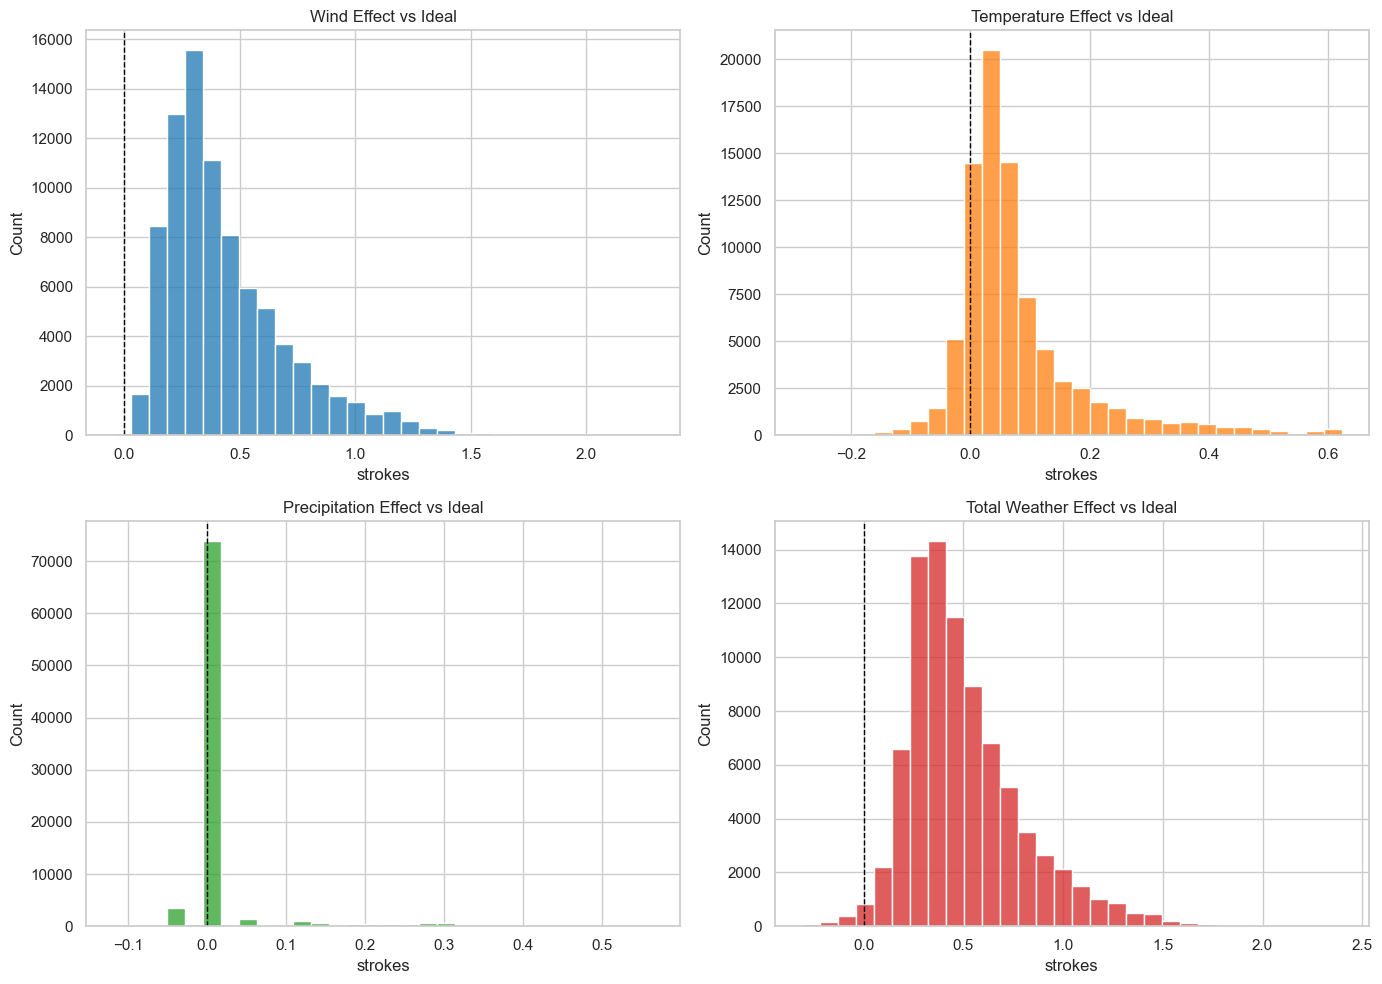

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(scored_df["estimated_wind_effect_vs_ideal"], bins=30, ax=axes[0, 0], color="#1f77b4")
axes[0, 0].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[0, 0].set_title("Wind Effect vs Ideal")
axes[0, 0].set_xlabel("strokes")

sns.histplot(scored_df["estimated_temperature_effect_vs_ideal"], bins=30, ax=axes[0, 1], color="#ff7f0e")
axes[0, 1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[0, 1].set_title("Temperature Effect vs Ideal")
axes[0, 1].set_xlabel("strokes")

sns.histplot(scored_df["estimated_precip_effect_vs_ideal"], bins=30, ax=axes[1, 0], color="#2ca02c")
axes[1, 0].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[1, 0].set_title("Precipitation Effect vs Ideal")
axes[1, 0].set_xlabel("strokes")

sns.histplot(scored_df["estimated_total_weather_effect_vs_ideal"], bins=30, ax=axes[1, 1], color="#d62728")
axes[1, 1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title("Total Weather Effect vs Ideal")
axes[1, 1].set_xlabel("strokes")

plt.tight_layout()
plt.show()


In [24]:
pdp_base_df = test_prepped.copy()
print("Rows in PDP base frame:", len(pdp_base_df))


Rows in PDP base frame: 83969


In [35]:
# -----------------------------------------------------------------------------
# Wind effect vs ideal PDP
# -----------------------------------------------------------------------------

wind_grid_mph = [0, 2, 5, 8, 12, 16]
wind_grid_mps = [x * MPH_TO_MPS for x in wind_grid_mph]
IDEAL_GUST_GAP_MPH = max(0.0, IDEAL_WIND_GUST_REFERENCE_MPH - IDEAL_WIND_REFERENCE_MPH)


def candidate_gust_from_wind_mph(wind_speed_mph: float) -> float:
    return max(wind_speed_mph, wind_speed_mph + IDEAL_GUST_GAP_MPH)


def build_wind_actual_design(base_df: pd.DataFrame, grid_value_mps: float) -> pd.DataFrame:
    wind_speed_mph = grid_value_mps * MPS_TO_MPH
    wind_gust_mph = candidate_gust_from_wind_mph(wind_speed_mph)
    return build_stage2_design_df(
        base_df,
        wind_speed_mps=grid_value_mps,
        wind_gust_mps=wind_gust_mph * MPH_TO_MPS,
    )


def build_wind_reference_design(base_df: pd.DataFrame, grid_value_mps: float) -> pd.DataFrame:
    return build_stage2_design_df(
        base_df,
        wind_speed_mps=IDEAL_WIND_REFERENCE_MPH * MPH_TO_MPS,
        wind_gust_mps=IDEAL_WIND_GUST_REFERENCE_MPH * MPH_TO_MPS,
    )


wind_effect_pdp_df = build_stage2_effect_curve(
    base_df=pdp_base_df,
    stage2_model=stage2_model,
    build_actual_design_fn=build_wind_actual_design,
    build_reference_design_fn=build_wind_reference_design,
    grid_values=wind_grid_mps,
)

wind_effect_pdp_df["wind_speed_mph"] = wind_effect_pdp_df["grid_value"] * MPS_TO_MPH
wind_effect_pdp_df


,grid_value,effect_mean,effect_median,effect_std,effect_p10,effect_p90,wind_speed_mph
0,0.00000,1.651542e-01,1.651542e-01,1.166692e-16,1.651542e-01,1.651542e-01,0.000000
1,0.89408,2.537240e-07,2.537240e-07,1.414554e-16,2.537240e-07,2.537240e-07,2.000003
2,2.23520,1.069469e-01,1.069469e-01,1.143138e-16,1.069469e-01,1.069469e-01,5.000008
3,3.57632,3.098080e-01,3.098080e-01,9.900902e-17,3.098080e-01,3.098080e-01,8.000013
4,5.36448,6.472605e-01,6.472605e-01,1.318237e-16,6.472605e-01,6.472605e-01,12.000020
5,7.15264,1.003081e+00,1.003081e+00,2.500066e-16,1.003081e+00,1.003081e+00,16.000027


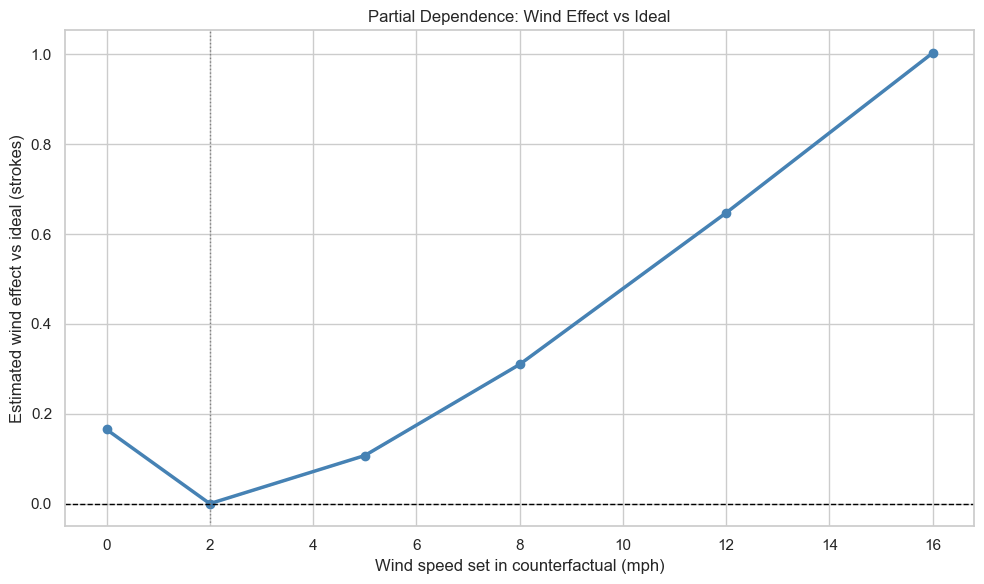

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(
    wind_effect_pdp_df["wind_speed_mph"],
    wind_effect_pdp_df["effect_mean"],
    marker="o",
    linewidth=2.5,
    color="steelblue",
)
plt.fill_between(
    wind_effect_pdp_df["wind_speed_mph"],
    wind_effect_pdp_df["effect_p10"],
    wind_effect_pdp_df["effect_p90"],
    color="steelblue",
    alpha=0.15,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.axvline(IDEAL_WIND_REFERENCE_MPH, color="gray", linestyle=":", linewidth=1)
plt.title("Partial Dependence: Wind Effect vs Ideal")
plt.xlabel("Wind speed set in counterfactual (mph)")
plt.ylabel("Estimated wind effect vs ideal (strokes)")
plt.tight_layout()
plt.show()


In [27]:
# -----------------------------------------------------------------------------
# Temperature effect vs ideal PDP
# -----------------------------------------------------------------------------

temperature_grid_c = [0, 5, 10, 12, 15, 18, 21, 24, 27, 30]


def build_temperature_actual_design(base_df: pd.DataFrame, grid_value_c: float) -> pd.DataFrame:
    return build_stage2_design_df(
        base_df,
        temp_c=grid_value_c,
    )


def build_temperature_reference_design(base_df: pd.DataFrame, grid_value_c: float) -> pd.DataFrame:
    return build_stage2_design_df(
        base_df,
        temp_c=IDEAL_TEMPERATURE_REFERENCE_C,
    )


temperature_effect_pdp_df = build_stage2_effect_curve(
    base_df=pdp_base_df,
    stage2_model=stage2_model,
    build_actual_design_fn=build_temperature_actual_design,
    build_reference_design_fn=build_temperature_reference_design,
    grid_values=temperature_grid_c,
)

temperature_effect_pdp_df["temperature_f"] = (temperature_effect_pdp_df["grid_value"] * 9.0 / 5.0) + 32.0
temperature_effect_pdp_df


,grid_value,effect_mean,effect_median,effect_std,effect_p10,effect_p90,temperature_f
0,0,0.352162,0.352162,9.458155e-17,0.352162,0.352162,32.0
1,5,0.194571,0.194571,9.610523e-17,0.194571,0.194571,41.0
2,10,0.102253,0.102253,9.084581e-17,0.102253,0.102253,50.0
3,12,0.078889,0.078889,6.475419e-17,0.078889,0.078889,53.6
4,15,0.053484,0.053484,7.203095e-17,0.053484,0.053484,59.0
5,18,0.034967,0.034967,8.138699e-17,0.034967,0.034967,64.4
6,21,0.018543,0.018543,8.315012e-17,0.018543,0.018543,69.8
7,24,0.000000,0.000000,0.000000e+00,0.000000,0.000000,75.2
8,27,-0.024837,-0.024837,8.636660e-17,-0.024837,-0.024837,80.6
9,30,-0.060143,-0.060143,8.849816e-17,-0.060143,-0.060143,86.0


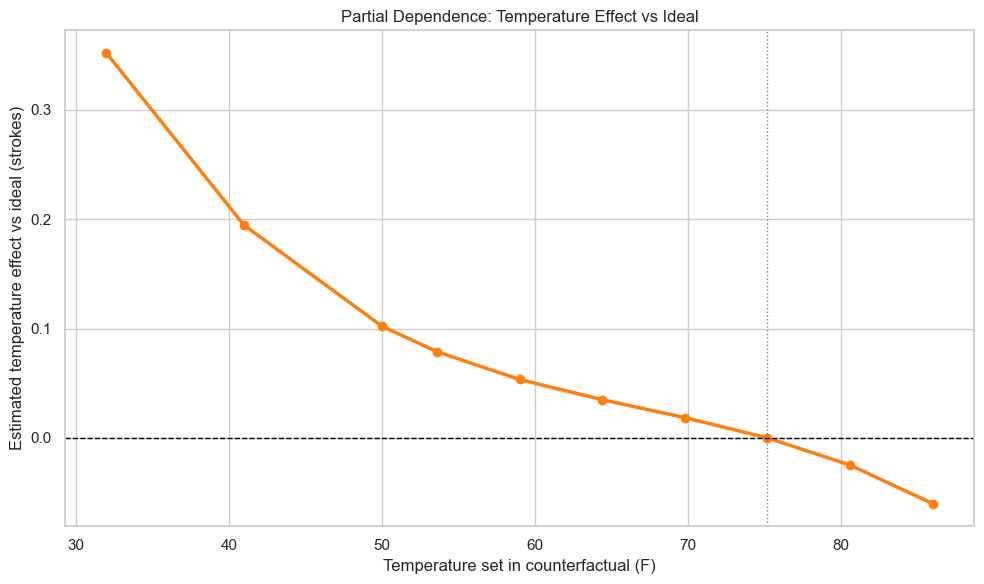

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(
    temperature_effect_pdp_df["temperature_f"],
    temperature_effect_pdp_df["effect_mean"],
    marker="o",
    linewidth=2.5,
    color="#ff7f0e",
)
plt.fill_between(
    temperature_effect_pdp_df["temperature_f"],
    temperature_effect_pdp_df["effect_p10"],
    temperature_effect_pdp_df["effect_p90"],
    color="#ff7f0e",
    alpha=0.15,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.axvline((IDEAL_TEMPERATURE_REFERENCE_C * 9.0 / 5.0) + 32.0, color="gray", linestyle=":", linewidth=1)
plt.title("Partial Dependence: Temperature Effect vs Ideal")
plt.xlabel("Temperature set in counterfactual (F)")
plt.ylabel("Estimated temperature effect vs ideal (strokes)")
plt.tight_layout()
plt.show()


In [29]:
# -----------------------------------------------------------------------------
# Temperature weather-adjustment score curve
# -----------------------------------------------------------------------------

temperature_score_curve_df = build_stage2_score_curve(
    base_df=pdp_base_df,
    stage2_model=stage2_model,
    build_design_fn=build_temperature_actual_design,
    grid_values=temperature_grid_c,
)

temperature_score_curve_df["temperature_f"] = (temperature_score_curve_df["grid_value"] * 9.0 / 5.0) + 32.0
temperature_score_curve_df


,grid_value,prediction_mean,prediction_median,prediction_std,prediction_p10,prediction_p90,temperature_f
0,0,0.254244,0.182225,0.265826,0.001083,0.619900,32.0
1,5,0.096653,0.024634,0.265826,-0.156508,0.462308,41.0
2,10,0.004335,-0.067684,0.265826,-0.248826,0.369990,50.0
3,12,-0.019029,-0.091048,0.265826,-0.272190,0.346626,53.6
4,15,-0.044434,-0.116453,0.265826,-0.297595,0.321221,59.0
5,18,-0.062951,-0.134970,0.265826,-0.316113,0.302704,64.4
6,21,-0.079375,-0.151394,0.265826,-0.332537,0.286280,69.8
7,24,-0.097918,-0.169937,0.265826,-0.351079,0.267737,75.2
8,27,-0.122755,-0.194774,0.265826,-0.375916,0.242901,80.6
9,30,-0.158061,-0.230080,0.265826,-0.411222,0.207594,86.0


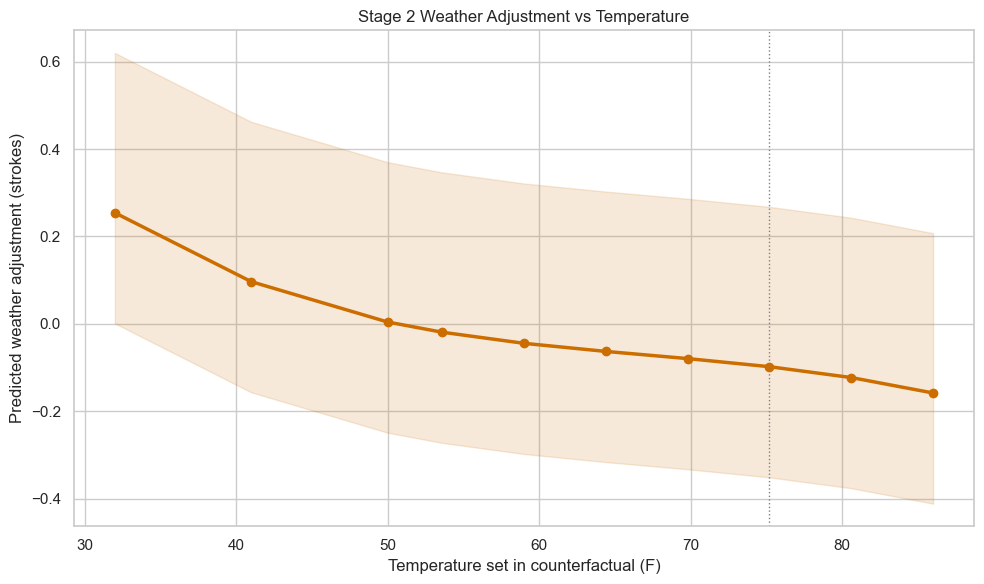

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(
    temperature_score_curve_df["temperature_f"],
    temperature_score_curve_df["prediction_mean"],
    marker="o",
    linewidth=2.5,
    color="#cc6d00",
)
plt.fill_between(
    temperature_score_curve_df["temperature_f"],
    temperature_score_curve_df["prediction_p10"],
    temperature_score_curve_df["prediction_p90"],
    color="#cc6d00",
    alpha=0.15,
)
plt.axvline((IDEAL_TEMPERATURE_REFERENCE_C * 9.0 / 5.0) + 32.0, color="gray", linestyle=":", linewidth=1)
plt.title("Stage 2 Weather Adjustment vs Temperature")
plt.xlabel("Temperature set in counterfactual (F)")
plt.ylabel("Predicted weather adjustment (strokes)")
plt.tight_layout()
plt.show()


In [31]:
# -----------------------------------------------------------------------------
# Objective-ish counterfactual scorecard
# -----------------------------------------------------------------------------

counterfactual_scorecard_df = pd.DataFrame(
    [
        {
            "experiment": EXPERIMENT_NAME,
            "stage1_valid_rmse": float(stage1_metrics_df.loc[stage1_metrics_df["split"] == "valid", "rmse"].iloc[0]),
            "combined_valid_rmse": float(combined_metrics_df.loc[combined_metrics_df["split"] == "valid", "rmse"].iloc[0]),
            "combined_test_rmse": float(combined_metrics_df.loc[combined_metrics_df["split"] == "test", "rmse"].iloc[0]),
            "train_valid_rmse_gap": float(
                combined_metrics_df.loc[combined_metrics_df["split"] == "train", "rmse"].iloc[0]
                - combined_metrics_df.loc[combined_metrics_df["split"] == "valid", "rmse"].iloc[0]
            ),
            "ideal_temperature_f": float((IDEAL_TEMPERATURE_REFERENCE_C * 9.0 / 5.0) + 32.0),
            "ideal_temp_on_boundary": bool(
                IDEAL_TEMPERATURE_REFERENCE_C == min(ideal_search_config["temperature_c"])
                or IDEAL_TEMPERATURE_REFERENCE_C == max(ideal_search_config["temperature_c"])
            ),
            "wind_pdp_total_variation": total_variation(wind_effect_pdp_df["effect_mean"]),
            "wind_pdp_second_diff_roughness": second_difference_roughness(wind_effect_pdp_df["effect_mean"]),
            "temperature_pdp_total_variation": total_variation(temperature_effect_pdp_df["effect_mean"]),
            "temperature_pdp_second_diff_roughness": second_difference_roughness(temperature_effect_pdp_df["effect_mean"]),
            "precip_pdp_total_variation": total_variation(precip_effect_pdp_df["effect_mean"]),
            "precip_pdp_second_diff_roughness": second_difference_roughness(precip_effect_pdp_df["effect_mean"]),
            "wind_pdp_nonmonotone_steps": int((np.diff(wind_effect_pdp_df["effect_mean"].to_numpy()) < -0.10).sum()),
            "precip_pdp_nonmonotone_steps": int((np.diff(precip_effect_pdp_df["effect_mean"].to_numpy()) < -0.10).sum()),
        }
    ]
)

counterfactual_scorecard_df


NameError: name 'precip_effect_pdp_df' is not defined

In [ ]:
scored_df[scored_df.round_wind]

,event_year,tourn_id,round_number,player_key,course_id,layout_id,division,player_rating,actual_round_strokes,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,round_strokes_over_par,round_length_over_par,wind_x_round_length,gust_x_round_length,wind_x_player_rating,predicted_round_strokes_stage1_baseline,predicted_weather_adjustment_observed,predicted_round_strokes,round_residual_strokes,predicted_weather_adjustment_wind_reference_ideal,predicted_weather_adjustment_temperature_reference_ideal,predicted_weather_adjustment_precip_reference_ideal,predicted_weather_adjustment_total_weather_reference_ideal,predicted_round_strokes_wind_reference_ideal,predicted_round_strokes_temperature_reference_ideal,predicted_round_strokes_precip_reference_ideal,predicted_round_strokes_total_weather_reference_ideal,estimated_wind_effect_vs_ideal,estimated_temperature_effect_vs_ideal,estimated_precip_effect_vs_ideal,estimated_total_weather_effect_vs_ideal
405787,2025,95243,1,PDGA#150233,240431,733407,MA3,853.0,82.0,22,7047.0,320.318182,71.0,3.227273,4.15,4.15,7.5,7.5,15.4,0.0,0.0,1020.2,61.0,11.0,99.253521,29245.05,52852.5,3539.95,81.200738,0.038595,81.239332,0.760668,-0.560292,-0.012136,0.038595,-0.524673,80.640446,81.188601,81.239332,80.676064,0.598886,0.050731,0.000000,0.563268
163523,2026,97670,2,PDGA#320120,24750,740810,MA40,744.0,111.0,18,10780.0,598.888889,70.0,3.888889,2.90,2.90,5.7,5.7,18.4,0.0,0.0,1017.3,32.0,41.0,154.000000,31262.00,61446.0,2157.60,105.901595,-0.339740,105.561855,5.438145,-0.727364,-0.372489,-0.339740,-0.524673,105.174231,105.529106,105.561855,105.376922,0.387624,0.032749,0.000000,0.184933
145680,2025,93650,1,PDGA#213243,25329,716237,MPO,1000.0,50.0,18,4426.0,245.888889,54.0,3.000000,2.84,2.84,6.1,6.1,26.1,1.8,0.1,1016.0,84.0,-4.0,81.962963,12569.84,26998.6,2840.00,44.222861,-0.158426,44.064435,5.935565,-0.565837,-0.141949,-0.115740,-0.524673,43.657024,44.080912,44.107121,43.698188,0.407411,-0.016476,-0.042686,0.366248
193881,2025,98617,1,PDGA#20175,204286,739590,MP50,896.0,60.0,18,5516.0,306.444444,57.0,3.166667,3.59,3.59,7.2,7.2,-1.1,0.0,0.0,1014.8,87.0,3.0,96.771930,19802.44,39715.2,3216.64,59.026814,0.425450,59.452264,0.547736,-0.101011,0.032002,0.425450,-0.524673,58.925804,59.058816,59.452264,58.502141,0.526460,0.393448,0.000000,0.950123
21439,2025,94448,1,PDGA#190976,303567,727345,MA2,911.0,73.0,18,7397.0,410.944444,64.0,3.555556,1.47,1.47,2.9,2.9,15.8,0.0,0.0,1018.3,84.0,9.0,115.578125,10873.59,21451.3,1339.17,69.721861,-0.276457,69.445403,3.554597,-0.453669,-0.324546,-0.276457,-0.524673,69.268192,69.397315,69.445403,69.197188,0.177212,0.048088,0.000000,0.248216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184026,2025,93221,2,PDGA#91116,27753,720257,MA50,851.0,63.0,20,5049.0,252.450000,60.0,3.000000,1.48,1.48,3.4,3.4,15.2,0.0,0.0,1014.7,75.0,3.0,84.150000,7472.52,17166.6,1259.48,62.496905,-0.285003,62.211902,0.788098,-0.501706,-0.337096,-0.285003,-0.524673,61.995199,62.159809,62.211902,61.972232,0.216703,0.052093,0.000000,0.239670
33438,2025,90979,1,PDGA#266303,274701,721141,MA1,931.0,79.0,27,9390.0,347.777778,86.0,3.185185,0.89,0.89,2.8,2.8,11.7,0.0,0.0,1017.6,45.0,-7.0,109.186047,8357.10,26292.0,828.59,82.846496,-0.371968,82.474528,-3.474528,-0.613406,-0.453979,-0.371968,-0.524673,82.233089,82.392517,82.474528,82.321822,0.241439,0.082011,0.000000,0.152706
141757,2025,92842,2,PDGA#312420,25289,721374,MA4,788.0,63.0,18,5154.0,286.333333,62.0,3.444444,2.38,2.38,5.3,5.3,22.8,0.0,0.0,1017.7,86.0,1.0,83.129032,12266.52,27316.2,1875.44,66.756157,-0.149487,66.606670,-3.606670,-0.485247,-0.157425,-0.149487,-0.524673,66.270909,66.598732,66.60667

In [33]:
regression_metrics(scored_df.predicted_round_strokes, scored_df.actual_round_strokes)

{'mae': 2.9825990595956333,
 'rmse': 3.9280234651391104,
 'r2': 0.8363231589854097}

In [ ]:
regression_metrics(scored_df.predicted_round_strokes_stage1_baseline, scored_df.actual_round_strokes)

{'mae': 2.9930905340792746,
 'rmse': 3.9409449936412777,
 'r2': 0.8347053900428724}